<a href="https://colab.research.google.com/github/411231032/BagusTriyadi.githubio/blob/main/Copy_of_Tugas_Database_Perpustakaan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Database, tabel, dan data berhasil dibuat.

Daftar Peminjaman Lengkap:


,id,nama,judul,tgl_pinjam,tgl_kembali
0,1,Andi,Laskar Pelangi,2026-05-01,2026-05-07
1,2,Andi,Bumi,2026-05-03,2026-05-10
2,3,Budi,Negeri 5 Menara,2026-05-05,None
3,4,Citra,Perahu Kertas,2026-05-08,2026-05-15



Jumlah Buku yang Dipinjam Tiap Anggota:


,nama,jumlah_buku_dipinjam
0,Andi,2
1,Budi,1
2,Citra,1



Data Peminjaman dengan Durasi:


,id,nama,judul,tgl_pinjam,tgl_kembali,durasi_hari
0,1,Andi,Laskar Pelangi,2026-05-01,2026-05-07,6.0
1,2,Andi,Bumi,2026-05-03,2026-05-10,7.0
2,3,Budi,Negeri 5 Menara,2026-05-05,NaT,NaN
3,4,Citra,Perahu Kertas,2026-05-08,2026-05-15,7.0



Buku yang Belum Dikembalikan:


,id,nama,judul,tgl_pinjam,tgl_kembali,durasi_hari
2,3,Budi,Negeri 5 Menara,2026-05-05,NaT,NaN


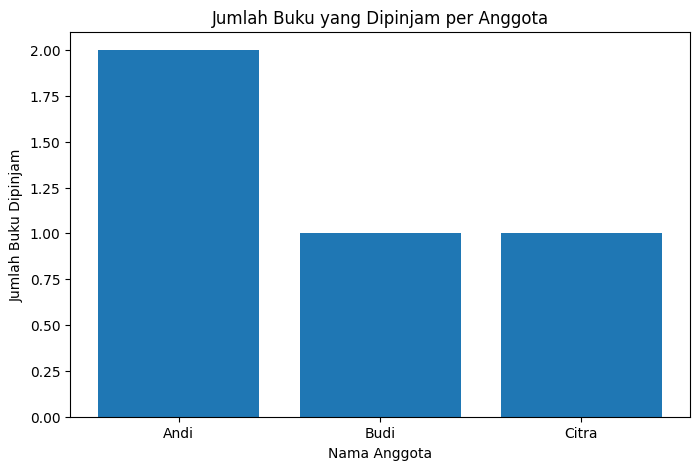

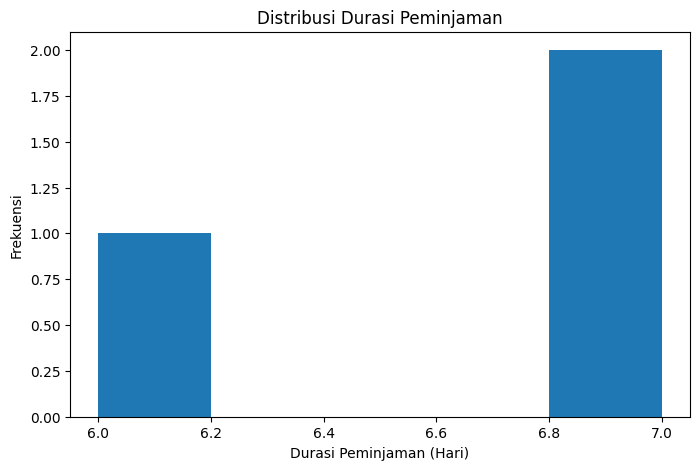


Kesimpulan:
1. Database perpustakaan berhasil dibuat menggunakan SQLite.
2. Terdapat 5 data buku, 3 data anggota, dan 4 transaksi peminjaman.
3. Salah satu peminjaman belum dikembalikan karena tgl_kembali bernilai NULL.
4. Data peminjaman berhasil ditampilkan menggunakan JOIN.
5. Jumlah buku yang dipinjam tiap anggota berhasil dihitung menggunakan GROUP BY.
6. Data berhasil dianalisis menggunakan pandas dan divisualisasikan dengan matplotlib.



In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Membuat koneksi database
conn = sqlite3.connect("perpustakaan.db")
cursor = conn.cursor()

# 2. Membuat tabel
cursor.execute("""
CREATE TABLE IF NOT EXISTS buku (
    id INTEGER PRIMARY KEY,
    judul TEXT,
    penulis TEXT,
    tahun INTEGER
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS anggota (
    id INTEGER PRIMARY KEY,
    nama TEXT,
    email TEXT
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS peminjaman (
    id INTEGER PRIMARY KEY,
    id_anggota INTEGER,
    id_buku INTEGER,
    tgl_pinjam TEXT,
    tgl_kembali TEXT,
    FOREIGN KEY (id_anggota) REFERENCES anggota(id),
    FOREIGN KEY (id_buku) REFERENCES buku(id)
)
""")

# 3. Menghapus data lama agar tidak error saat dijalankan ulang
cursor.execute("DELETE FROM peminjaman")
cursor.execute("DELETE FROM buku")
cursor.execute("DELETE FROM anggota")
conn.commit()

# 4. Menambahkan data buku
data_buku = [
    (1, "Laskar Pelangi", "Andrea Hirata", 2005),
    (2, "Bumi", "Tere Liye", 2014),
    (3, "Negeri 5 Menara", "Ahmad Fuadi", 2009),
    (4, "Ayat Ayat Cinta", "Habiburrahman", 2004),
    (5, "Perahu Kertas", "Dee Lestari", 2009)
]

cursor.executemany("INSERT INTO buku VALUES (?, ?, ?, ?)", data_buku)

# 5. Menambahkan data anggota
data_anggota = [
    (1, "Andi", "andi@gmail.com"),
    (2, "Budi", "budi@gmail.com"),
    (3, "Citra", "citra@gmail.com")
]

cursor.executemany("INSERT INTO anggota VALUES (?, ?, ?)", data_anggota)

# 6. Menambahkan data peminjaman
data_peminjaman = [
    (1, 1, 1, "2026-05-01", "2026-05-07"),
    (2, 1, 2, "2026-05-03", "2026-05-10"),
    (3, 2, 3, "2026-05-05", None),
    (4, 3, 5, "2026-05-08", "2026-05-15")
]

cursor.executemany("INSERT INTO peminjaman VALUES (?, ?, ?, ?, ?)", data_peminjaman)

conn.commit()

print("Database, tabel, dan data berhasil dibuat.")

# 7. Menampilkan daftar peminjaman lengkap dengan JOIN
query_join = """
SELECT
    peminjaman.id,
    anggota.nama,
    buku.judul,
    peminjaman.tgl_pinjam,
    peminjaman.tgl_kembali
FROM peminjaman
JOIN anggota ON peminjaman.id_anggota = anggota.id
JOIN buku ON peminjaman.id_buku = buku.id
"""

df_peminjaman = pd.read_sql_query(query_join, conn)

print("\nDaftar Peminjaman Lengkap:")
display(df_peminjaman)

# 8. Menghitung jumlah buku dipinjam tiap anggota
query_group = """
SELECT
    anggota.nama,
    COUNT(peminjaman.id_buku) AS jumlah_buku_dipinjam
FROM peminjaman
JOIN anggota ON peminjaman.id_anggota = anggota.id
GROUP BY anggota.nama
"""

df_jumlah = pd.read_sql_query(query_group, conn)

print("\nJumlah Buku yang Dipinjam Tiap Anggota:")
display(df_jumlah)

# 9. Menghitung durasi peminjaman
df_peminjaman["tgl_pinjam"] = pd.to_datetime(df_peminjaman["tgl_pinjam"])
df_peminjaman["tgl_kembali"] = pd.to_datetime(df_peminjaman["tgl_kembali"])

df_peminjaman["durasi_hari"] = (
    df_peminjaman["tgl_kembali"] - df_peminjaman["tgl_pinjam"]
).dt.days

print("\nData Peminjaman dengan Durasi:")
display(df_peminjaman)

# 10. Menampilkan buku yang belum dikembalikan
belum_dikembalikan = df_peminjaman[df_peminjaman["tgl_kembali"].isna()]

print("\nBuku yang Belum Dikembalikan:")
display(belum_dikembalikan)

# 11. Visualisasi jumlah buku dipinjam per anggota
plt.figure(figsize=(8, 5))
plt.bar(df_jumlah["nama"], df_jumlah["jumlah_buku_dipinjam"])
plt.title("Jumlah Buku yang Dipinjam per Anggota")
plt.xlabel("Nama Anggota")
plt.ylabel("Jumlah Buku Dipinjam")
plt.show()

# 12. Visualisasi histogram durasi peminjaman
plt.figure(figsize=(8, 5))
plt.hist(df_peminjaman["durasi_hari"].dropna(), bins=5)
plt.title("Distribusi Durasi Peminjaman")
plt.xlabel("Durasi Peminjaman (Hari)")
plt.ylabel("Frekuensi")
plt.show()

# 13. Kesimpulan
print("""
Kesimpulan:
1. Database perpustakaan berhasil dibuat menggunakan SQLite.
2. Terdapat 5 data buku, 3 data anggota, dan 4 transaksi peminjaman.
3. Salah satu peminjaman belum dikembalikan karena tgl_kembali bernilai NULL.
4. Data peminjaman berhasil ditampilkan menggunakan JOIN.
5. Jumlah buku yang dipinjam tiap anggota berhasil dihitung menggunakan GROUP BY.
6. Data berhasil dianalisis menggunakan pandas dan divisualisasikan dengan matplotlib.
""")

conn.close()